# Deskriptiv Statistik - En Introduktion

## Indhold
1. **Mål for Central Tendens** (Central Tendency Measures)
   - Gennemsnit (Mean)
   - Median
   - Typetal (Mode)

2. **Mål for Variabilitet/Spredning** (Measures of Variability/Dispersion)
   - Range (Variationsbredde)
   - Varians (Variance)
   - Standardafvigelse (Standard Deviation)
   - Interkvartilområde (IQR)

3. **Frekvensfordelinger** (Frequency Distributions)
   - Histogrammer
   - Frekvenstabeller
   - Kumulative frekvenser

Denne notebook bruger data fra `player_stats.csv`, som indeholder statistikker for fodboldspillere fra VM 2022.


In [ ]:
# Import af nødvendige biblioteker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sæt stil for plots
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Indlæs data
df = pd.read_csv('player_stats.csv')

# Vis første rækker og grundlæggende info
print("Rows and Columns:", df.shape)
print("\nFørste 5 rækker:")
df.head()


In [3]:
pd.__version__

'3.0.0'

In [4]:
# Vis grundlæggende information om datasættet
print("\nKolonner:                Datatyper:")
print(df.dtypes)



Kolonner:                Datatyper:
player                          str
position                        str
team                            str
age                             str
club                            str
birth_year                    int64
games                         int64
games_starts                  int64
minutes                       int64
minutes_90s                 float64
goals                         int64
assists                       int64
goals_pens                    int64
pens_made                     int64
pens_att                      int64
cards_yellow                  int64
cards_red                     int64
goals_per90                 float64
assists_per90               float64
goals_assists_per90         float64
goals_pens_per90            float64
goals_assists_pens_per90    float64
xg                          float64
npxg                        float64
xg_assist                   float64
npxg_xg_assist              float64
xg_per90                   

## 1. Mål for Central Tendens (Measures of Central Tendency)

Mål for central tendens beskriver "centret" eller den typiske værdi i et datasæt. De tre mest almindelige mål er:

### 1.1 Gennemsnit (Mean)
Gennemsnittet er summen af alle værdier divideret med antallet af observationer.

**Formel:** $\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$

### 1.2 Median
Medianen er den midterste værdi, når data er sorteret i stigende rækkefølge. Hvis der er et lige antal observationer, er medianen gennemsnittet af de to midterste værdier.

### 1.3 Typetal (Mode)
Typetallet er den værdi, der forekommer hyppigst i datasættet.


In [5]:
# Eksempel: Analysér mål (goals) for spillere
goals = df['goals'].dropna()

# Beregn mål for central tendens
mean_goals = goals.mean()
median_goals = goals.median()
mode_goals = goals.mode()

print("=" * 60)
print("MÅL FOR CENTRAL TENDENS - GOALS (Mål)")
print("=" * 60)
print(f"Gennemsnit (Mean): {mean_goals:.2f} mål")
print(f"Median: {median_goals:.2f} mål")
print(f"Typetal (Mode): {mode_goals.values[0]} mål (forekommer {goals.value_counts().iloc[0]} ({(goals.value_counts().iloc[0]/goals.shape[0])*100:.2f}%) gange ud af {goals.shape[0]})")

MÅL FOR CENTRAL TENDENS - GOALS (Mål)
Gennemsnit (Mean): 0.25 mål
Median: 0.00 mål
Typetal (Mode): 0 mål (forekommer 563 (82.79%) gange ud af 680)


In [6]:
# Eksempel: Analysér mål (goals) for angribere som har spillet mere end 150 minutter
goals = df[(df['position'] == 'FW') & (df['minutes'] >= 150)]['goals'].dropna()

# Beregn mål for central tendens
mean_goals = goals.mean()
median_goals = goals.median()
mode_goals = goals.mode()

print("=" * 60)
print("MÅL FOR CENTRAL TENDENS - GOALS (Mål)")
print("=" * 60)
print(f"Gennemsnit (Mean): {mean_goals:.2f} mål")
print(f"Median: {median_goals:.2f} mål")
print(f"Typetal (Mode): {mode_goals.values[0]} mål (forekommer {goals.value_counts().iloc[0]} ({(goals.value_counts().iloc[0]/goals.shape[0])*100:.2f}%) gange ud af {goals.shape[0]})")

MÅL FOR CENTRAL TENDENS - GOALS (Mål)
Gennemsnit (Mean): 1.11 mål
Median: 1.00 mål
Typetal (Mode): 0 mål (forekommer 34 (41.46%) gange ud af 82)


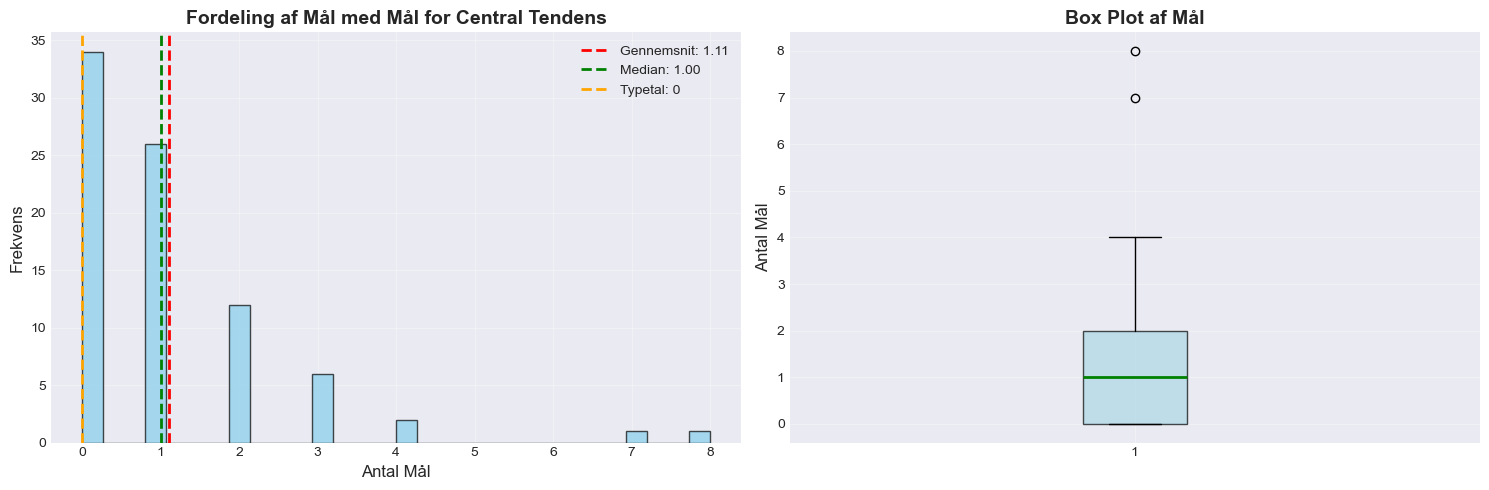


Observationer:
- Røde stiplede linje: Gennemsnit (påvirkes af ekstreme værdier)
- Grønne stiplede linje: Median (robust mod outliers)
- Orange stiplede linje: Typetal (hyppigste værdi)


In [7]:
# Visualisér mål for central tendens
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram med mål for central tendens
axes[0].hist(goals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(mean_goals, color='red', linestyle='--', linewidth=2, label=f'Gennemsnit: {mean_goals:.2f}')
axes[0].axvline(median_goals, color='green', linestyle='--', linewidth=2, label=f'Median: {median_goals:.2f}')
axes[0].axvline(mode_goals.values[0], color='orange', linestyle='--', linewidth=2, label=f'Typetal: {mode_goals.values[0]}')
axes[0].set_xlabel('Antal Mål', fontsize=12)
axes[0].set_ylabel('Frekvens', fontsize=12)
axes[0].set_title('Fordeling af Mål med Mål for Central Tendens', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
box_data = [goals]
axes[1].boxplot(box_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='green', linewidth=2))
axes[1].set_ylabel('Antal Mål', fontsize=12)
axes[1].set_title('Box Plot af Mål', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservationer:")
print("- Røde stiplede linje: Gennemsnit (påvirkes af ekstreme værdier)")
print("- Grønne stiplede linje: Median (robust mod outliers)")
print("- Orange stiplede linje: Typetal (hyppigste værdi)")


## 2. Mål for Variabilitet/Spredning (Measures of Variability/Dispersion)

Mål for variabilitet beskriver, hvor meget dataene spreder sig eller varierer. De hjælper os med at forstå konsistensen og spredningen i datasættet.

### 2.1 Range (Variationsbredde)
Range er forskellen mellem den største og mindste værdi.

**Formel:** $Range = x_{max} - x_{min}$

### 2.2 Varians (Variance)
Variansen måler den gennemsnitlige kvadratiske afstand fra gennemsnittet.

**Formel:** $s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}$ (sample variance)

### 2.3 Standardafvigelse (Standard Deviation)
Standardafvigelsen er kvadratroden af variansen og har samme enhed som dataene.

**Formel:** $s = \sqrt{s^2}$

### 2.4 Interkvartilområde (IQR)
IQR er forskellen mellem 75. percentil (Q3) og 25. percentil (Q1). Det er robust mod outliers.

**Formel:** $IQR = Q3 - Q1$


In [8]:
# Beregn mål for variabilitet for 'goals'

# Filter for Goals: FW og mindst 150 min
goals = df[(df['position'] == 'FW') & (df['minutes'] >= 150)]['goals'].dropna()

# Range
range_goals = goals.max() - goals.min()

# Varians og Standardafvigelse
variance_goals = goals.var(ddof=1)  # ddof=1 for sample variance
std_goals = goals.std(ddof=1)

# IQR (Interquartile Range)
q1_goals = goals.quantile(0.25)
q3_goals = goals.quantile(0.75)
iqr_goals = q3_goals - q1_goals
lower_whisker = goals[goals >= (q1_goals - 1.5 * iqr_goals)].min()
upper_whisker = goals[goals <= (q3_goals + 1.5 * iqr_goals)].max()

print("=" * 60)
print("MÅL FOR VARIABILITET - GOALS (Mål)")
print("=" * 60)
print(f"Range (Variationsbredde): {range_goals:.2f} ({goals.min()} til {goals.max()})")
print(f"Varians (Variance): {variance_goals:.2f}")
print(f"Standardafvigelse (Std Dev): {std_goals:.2f}")
print(f"Interkvartilområde (IQR): {iqr_goals:.2f}")
print(f"  - LW (Lower whisker): {lower_whisker:.2f}")
print(f"  - Q1 (25. percentil): {q1_goals:.2f}")
print(f"  - Q3 (75. percentil): {q3_goals:.2f}")
print(f"  - UW (Upper whisker): {upper_whisker:.2f}")
print("\nForklaring:")
print("- Range viser den totale spredning fra minimum til maximum")
print("- Standardafvigelse fortæller os, hvor meget værdierne typisk afviger fra gennemsnittet")
print("- IQR er mere robust og viser spredningen i midten af dataene (ignorerer ekstreme værdier)")


MÅL FOR VARIABILITET - GOALS (Mål)
Range (Variationsbredde): 8.00 (0 til 8)
Varians (Variance): 2.12
Standardafvigelse (Std Dev): 1.46
Interkvartilområde (IQR): 2.00
  - LW (Lower whisker): 0.00
  - Q1 (25. percentil): 0.00
  - Q3 (75. percentil): 2.00
  - UW (Upper whisker): 4.00

Forklaring:
- Range viser den totale spredning fra minimum til maximum
- Standardafvigelse fortæller os, hvor meget værdierne typisk afviger fra gennemsnittet
- IQR er mere robust og viser spredningen i midten af dataene (ignorerer ekstreme værdier)


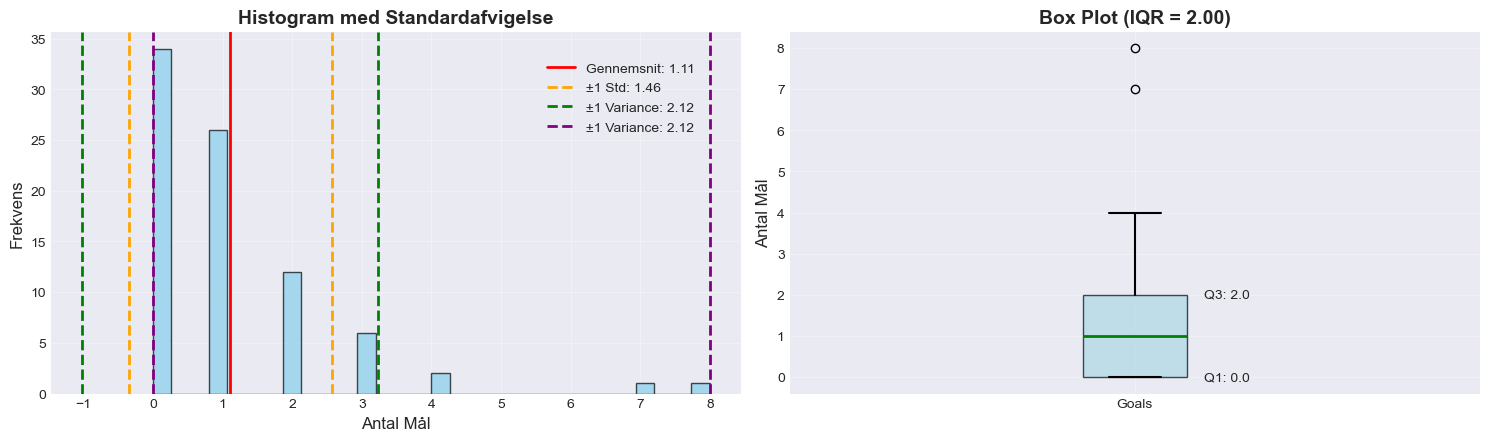

In [9]:
# Visualisér variabilitet
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram med standardafvigelse markeret
axes[0].hist(goals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
mean_goals = goals.mean()
axes[0].axvline(mean_goals, color='red', linestyle='-', linewidth=2, label=f'Gennemsnit: {mean_goals:.2f}')
axes[0].axvline(mean_goals + std_goals, color='orange', linestyle='--', linewidth=2, label=f'±1 Std: {std_goals:.2f}')
axes[0].axvline(mean_goals - std_goals, color='orange', linestyle='--', linewidth=2)
axes[0].axvline(mean_goals + variance_goals, color='green', linestyle='--', linewidth=2, label=f'±1 Variance: {variance_goals:.2f}')
axes[0].axvline(mean_goals - variance_goals, color='green', linestyle='--', linewidth=2)
axes[0].axvline(goals.max(), color='purple', linestyle='--', linewidth=2, label=f'±1 Variance: {variance_goals:.2f}')
axes[0].axvline(goals.min(), color='purple', linestyle='--', linewidth=2)
axes[0].set_xlabel('Antal Mål', fontsize=12)
axes[0].set_ylabel('Frekvens', fontsize=12)
axes[0].set_xticks(np.arange(-1, 9, 1))
axes[0].set_title('Histogram med Standardafvigelse', fontsize=14, fontweight='bold')
axes[0].legend(bbox_to_anchor=(0.70, 0.95))
axes[0].grid(True, alpha=0.3)

# 2. Box plot (viser IQR)
box_data = [goals]
box_props = dict(facecolor='lightblue', alpha=0.7)
median_props = dict(color='green', linewidth=2)
whisker_props = dict(color='black', linewidth=1.5)
cap_props = dict(color='black', linewidth=1.5)

# Lav boxplot
bp = axes[1].boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    boxprops=box_props,
    medianprops=median_props,
    whiskerprops=whisker_props,
    capprops=cap_props
)
axes[1].set_ylabel('Antal Mål', fontsize=12)
axes[1].set_title(f'Box Plot (IQR = {iqr_goals:.2f})', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Goals'])
axes[1].grid(True, alpha=0.3)
axes[1].text(1.1, q1_goals, f'Q1: {q1_goals:.1f}', fontsize=10, verticalalignment='center')
axes[1].text(1.1, q3_goals, f'Q3: {q3_goals:.1f}', fontsize=10, verticalalignment='center')



plt.tight_layout()
plt.show()


In [10]:
# Filter for Goals: FW og mindst 150 min
df_goals_filtered = df[(df['minutes'] >= 150) & (df['position'] == 'FW')]

# Filter for Assists: FW eller MF og mindst 150 min
df_assists_filtered = df[(df['minutes'] >= 150) & (df['position'].isin(['FW', 'MF']))]


# Lav dataframe med variabilitet
variability_metrics = pd.DataFrame({
    'Variabel': ['goals', 'assists'],
    'Range': [
        df_goals_filtered['goals'].max() - df_goals_filtered['goals'].min(),
        df_assists_filtered['assists'].max() - df_assists_filtered['assists'].min()
    ],
    'Varians': [
        df_goals_filtered['goals'].var(ddof=1),
        df_assists_filtered['assists'].var(ddof=1)
    ],
    'Std. Afv.': [
        df_goals_filtered['goals'].std(ddof=1),
        df_assists_filtered['assists'].std(ddof=1)
    ],
    'IQR': [
        df_goals_filtered['goals'].quantile(0.75) - df_goals_filtered['goals'].quantile(0.25),
        df_assists_filtered['assists'].quantile(0.75) - df_assists_filtered['assists'].quantile(0.25)
    ]
})

print("Sammenligning af Variabilitet:")
print("=" * 80)
print(variability_metrics.to_string(index=False, col_space=15))
print("\nForklaring:")
print("- Variabler med høj standardafvigelse har større spredning")
print("- IQR er mindre påvirket af outliers end range og standardafvigelse")

Sammenligning af Variabilitet:
       Variabel           Range         Varians       Std. Afv.             IQR
          goals               8        2.123607        1.457260             2.0
        assists               3        0.493670        0.702617             1.0

Forklaring:
- Variabler med høj standardafvigelse har større spredning
- IQR er mindre påvirket af outliers end range og standardafvigelse


In [11]:
# Eksempel: Coefficient of Variation (CV) - relativ variabilitet

cv_goals = (std_goals / mean_goals) * 100 if mean_goals != 0 else 0
cv_assists = (df_assists_filtered['assists'].std() / df_assists_filtered['assists'].mean()) * 100 if df_assists_filtered['assists'].mean() != 0 else 0

print("Coefficient of Variation (CV) - Relativ Variabilitet")
print("=" * 60)
print(f"Goals   CV: {cv_goals:.2f}%")
print(f"Assists CV: {cv_assists:.2f}%")
print("\nForklaring:")
print("- CV måler relativ variabilitet. Højere CV betyder større relativ spredning.")
print("- Dette er nyttigt når man sammenligner variabler med forskellige gennemsnit.")

Coefficient of Variation (CV) - Relativ Variabilitet
Goals   CV: 131.31%
Assists CV: 189.32%

Forklaring:
- CV måler relativ variabilitet. Højere CV betyder større relativ spredning.
- Dette er nyttigt når man sammenligner variabler med forskellige gennemsnit.


## 3. Frekvensfordelinger (Frequency Distributions)

Frekvensfordelinger viser, hvor ofte forskellige værdier eller værdiintervaller forekommer i datasættet. De hjælper os med at forstå formen af datafordelingen.

### 3.1 Frekvenstabeller
Frekvenstabeller viser antallet af gange hver værdi eller kategori forekommer.

### 3.2 Histogrammer
Histogrammer er grafiske repræsentationer af frekvensfordelinger, hvor data er grupperet i intervaller (bins).

### 3.3 Kumulative Frekvenser
Kumulative frekvenser viser den akkumulerede frekvens op til en given værdi.


In [12]:
# Frekvenstabel for goals
print("=" * 60)
print("FREKVENSTABEL - GOALS (Mål)")
print("=" * 60)
freq_table = goals.value_counts().sort_index()
freq_table_df = pd.DataFrame({
    'Antal Mål': freq_table.index,
    'Frekvens (Antal spillere)': freq_table.values,
    'Relativ Frekvens (%)': (freq_table.values / len(goals) * 100).round(2)
})
print(freq_table_df.head(15).to_string(index=False))
print(f"\nTotal antal spillere: {len(goals)}")


FREKVENSTABEL - GOALS (Mål)
 Antal Mål  Frekvens (Antal spillere)  Relativ Frekvens (%)
         0                         34                 41.46
         1                         26                 31.71
         2                         12                 14.63
         3                          6                  7.32
         4                          2                  2.44
         7                          1                  1.22
         8                          1                  1.22

Total antal spillere: 82


In [13]:
# Frekvenstabel for kategoriske variabler - Position
print("=" * 60)
print("FREKVENSTABEL - POSITION (Spillerposition)")
print("=" * 60)
position_freq = df['position'].value_counts()
position_freq_df = pd.DataFrame({
    'Position': position_freq.index,
    'Frekvens': position_freq.values,
    'Relativ Frekvens (%)': (position_freq.values / len(df) * 100).round(2)
})
print(position_freq_df.to_string(index=False))
print(f"\nTotal antal spillere: {len(df)}")

FREKVENSTABEL - POSITION (Spillerposition)
Position  Frekvens  Relativ Frekvens (%)
      DF       228                 33.53
      MF       226                 33.24
      FW       185                 27.21
      GK        41                  6.03

Total antal spillere: 680


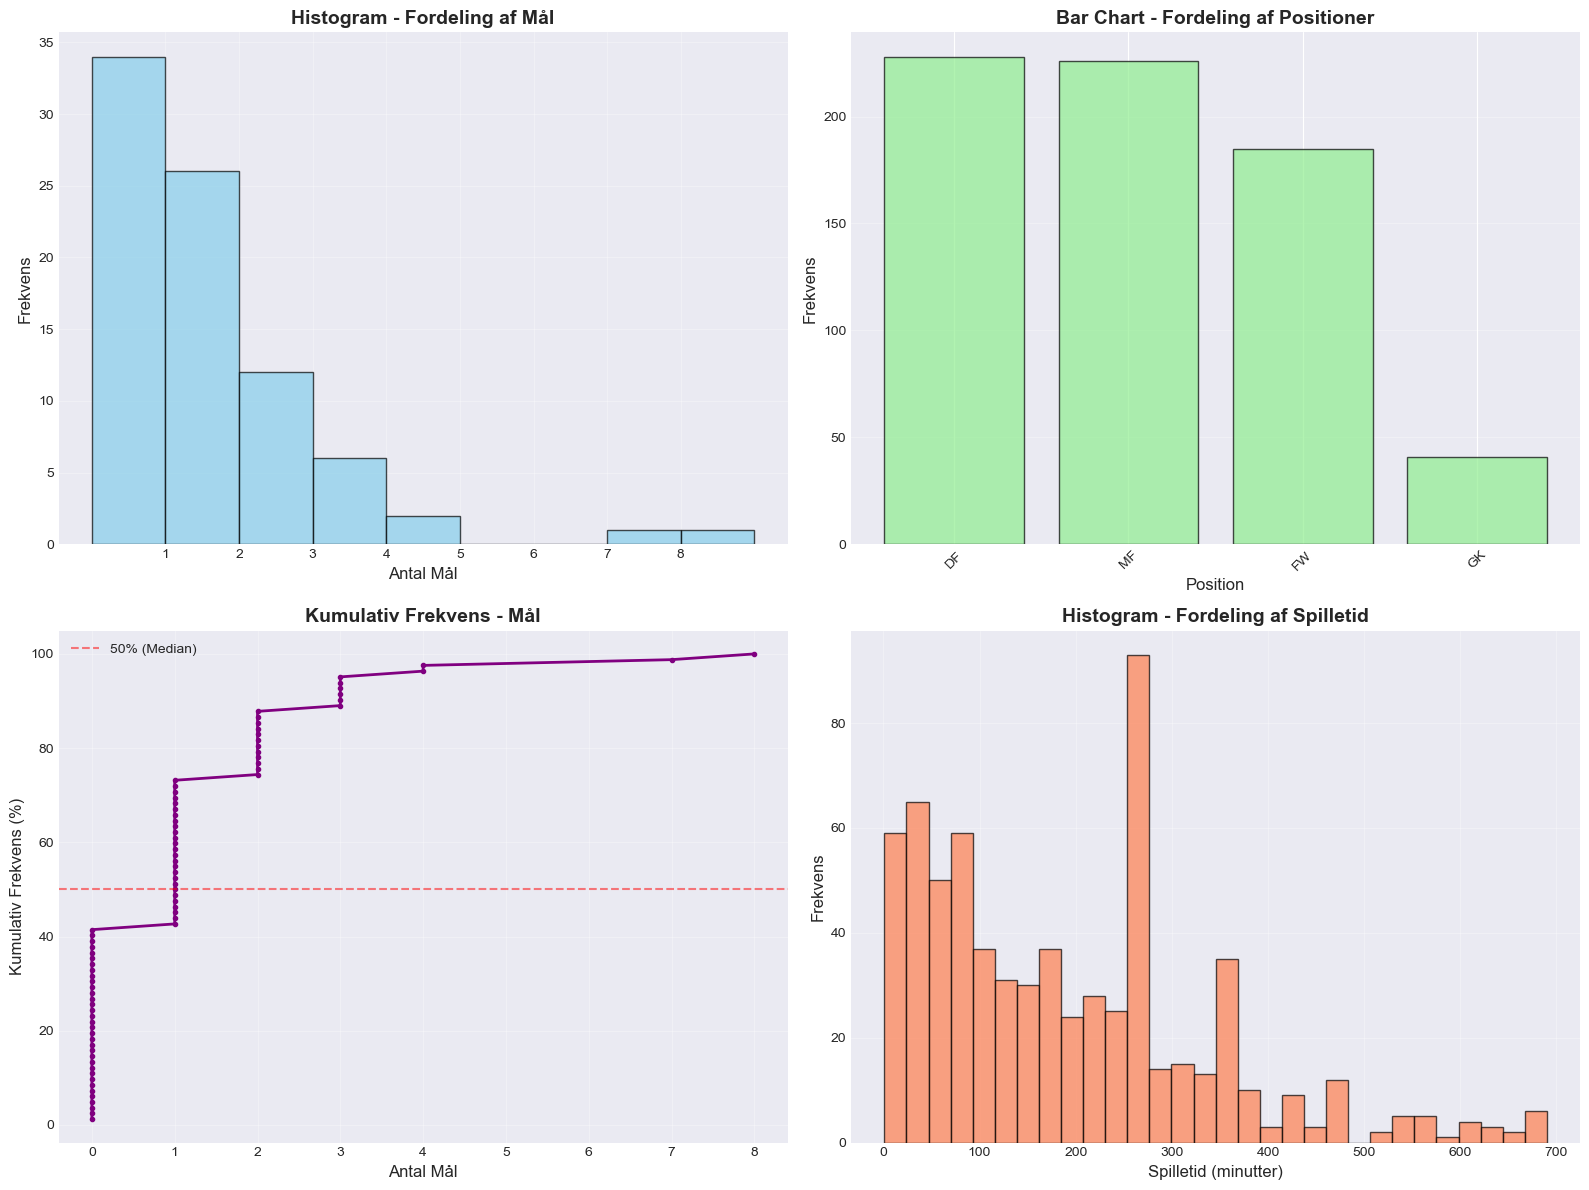

In [14]:
# Visualisér frekvensfordelinger
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram for goals
axes[0, 0].hist(goals, bins=range(int(goals.max())+2), edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Antal Mål', fontsize=12)
axes[0, 0].set_ylabel('Frekvens', fontsize=12)
axes[0, 0].set_title('Histogram - Fordeling af Mål', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(np.arange(1, 9))
axes[0, 0].grid(True, alpha=0.3)

# 2. Bar chart for position
position_counts = df['position'].value_counts()
axes[0, 1].bar(position_counts.index, position_counts.values, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Position', fontsize=12)
axes[0, 1].set_ylabel('Frekvens', fontsize=12)
axes[0, 1].set_title('Bar Chart - Fordeling af Positioner', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Kumulativ frekvens for goals
goals_sorted = np.sort(goals)
cumulative_freq = np.arange(1, len(goals_sorted) + 1) / len(goals_sorted) * 100
axes[1, 0].plot(goals_sorted, cumulative_freq, marker='o', markersize=3, linewidth=2, color='purple')
axes[1, 0].set_xlabel('Antal Mål', fontsize=12)
axes[1, 0].set_ylabel('Kumulativ Frekvens (%)', fontsize=12)
axes[1, 0].set_title('Kumulativ Frekvens - Mål', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% (Median)')
axes[1, 0].legend()

# 4. Histogram for minutes med forskellige bin-størrelser
axes[1, 1].hist(df['minutes'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Spilletid (minutter)', fontsize=12)
axes[1, 1].set_ylabel('Frekvens', fontsize=12)
axes[1, 1].set_title('Histogram - Fordeling af Spilletid', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
goals = df[(df['position'] == 'FW') & (df['minutes'] >= 150)]['goals'].dropna()
# Intervaller
bins = [0, 1, 2, 3, 5, 10, max(goals.max()+1, 11)]
labels = ['0', '1', '2', '3-4', '5-9', '10+']

# Gruppering
goals_grouped = pd.cut(goals, bins=bins, labels=labels, right=False)

# Frekvensberegning
grouped_freq = goals_grouped.value_counts().sort_index()

# Lav DataFrame
grouped_freq_df = pd.DataFrame({
    'Mål Interval': grouped_freq.index,
    'Frekvens': grouped_freq.values,
    'Relativ Frekvens (%)': (grouped_freq.values / len(goals) * 100).round(2),
    'Kumulativ Frekvens': grouped_freq.cumsum().values,
    'Kumulativ %': (grouped_freq.cumsum() / len(goals) * 100).round(2)
})

print(grouped_freq_df.to_string(index=False))
print(f"\nTotal antal spillere: {len(goals)}")

Mål Interval  Frekvens  Relativ Frekvens (%)  Kumulativ Frekvens  Kumulativ %
           0        34                 41.46                  34        41.46
           1        26                 31.71                  60        73.17
           2        12                 14.63                  72        87.80
         3-4         8                  9.76                  80        97.56
         5-9         2                  2.44                  82       100.00
         10+         0                  0.00                  82       100.00

Total antal spillere: 82


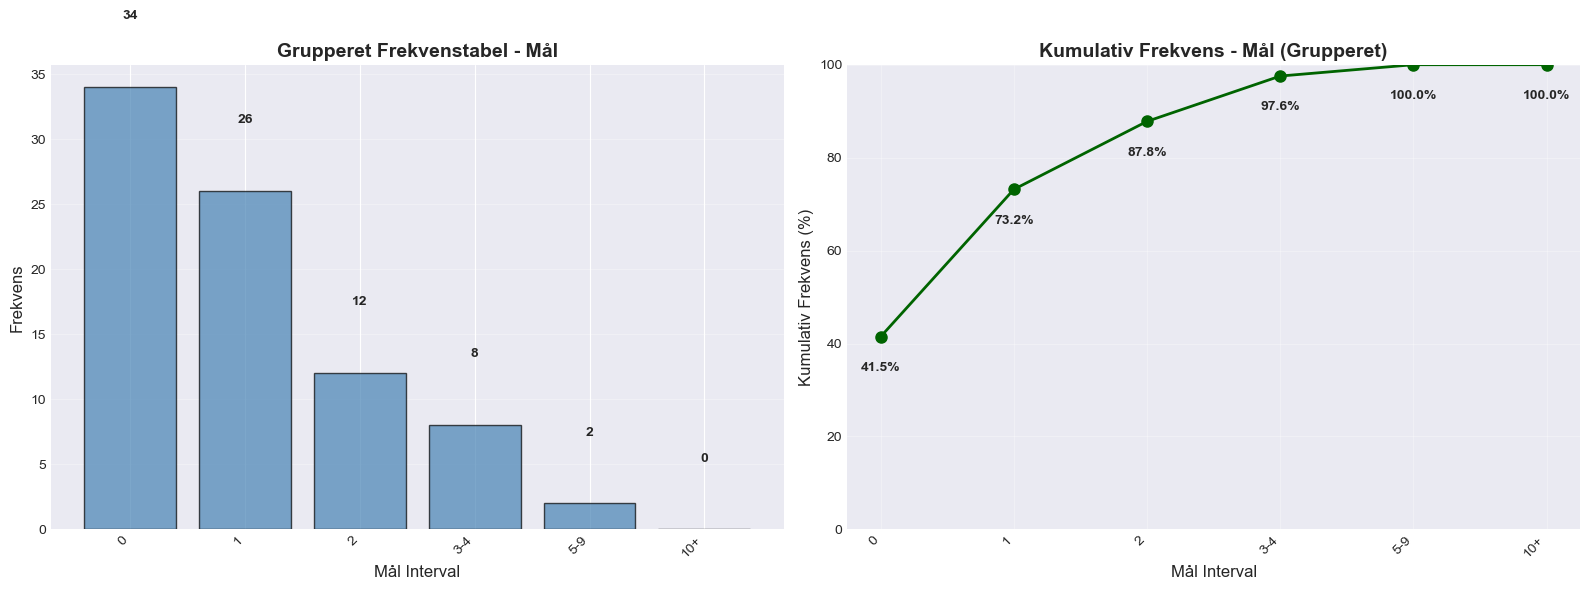

In [16]:
# Visualisér grupperet frekvenstabel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for grupperet frekvens
grouped_freq_sorted = grouped_freq.sort_index()
axes[0].bar(range(len(grouped_freq_sorted)), grouped_freq_sorted.values, 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(grouped_freq_sorted)))
axes[0].set_xticklabels(grouped_freq_sorted.index, rotation=45, ha='right')
axes[0].set_xlabel('Mål Interval', fontsize=12)
axes[0].set_ylabel('Frekvens', fontsize=12)
axes[0].set_title('Grupperet Frekvenstabel - Mål', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Tilføj værdier på søjlerne
for i, v in enumerate(grouped_freq_sorted.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Kumulativ frekvens for grupperet data (i procent)
cumulative = grouped_freq.sort_index().cumsum()
cumulative_pct = cumulative / cumulative.iloc[-1] * 100

axes[1].plot(
    range(len(cumulative_pct)),
    cumulative_pct.values,
    marker='o',
    linewidth=2,
    markersize=8,
    color='darkgreen'
)

axes[1].set_xticks(range(len(cumulative_pct)))
axes[1].set_xticklabels(cumulative_pct.index, rotation=45, ha='right')

axes[1].set_xlabel('Mål Interval', fontsize=12)
axes[1].set_ylabel('Kumulativ Frekvens (%)', fontsize=12)
axes[1].set_title('Kumulativ Frekvens - Mål (Grupperet)', fontsize=14, fontweight='bold')

axes[1].set_ylim(0, 100)

axes[1].grid(True, alpha=0.3)

# Tilføj procentværdier på punkterne
for i, v in enumerate(cumulative_pct.values):
    axes[1].text(i, v - 8, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Sammenligning af Mål per Position (≥150 min):
          mean  median   std  count
position                           
DF        0.13     0.0  0.33    141
FW        1.11     1.0  1.46     82
GK        0.00     0.0  0.00     32
MF        0.25     0.0  0.47    112


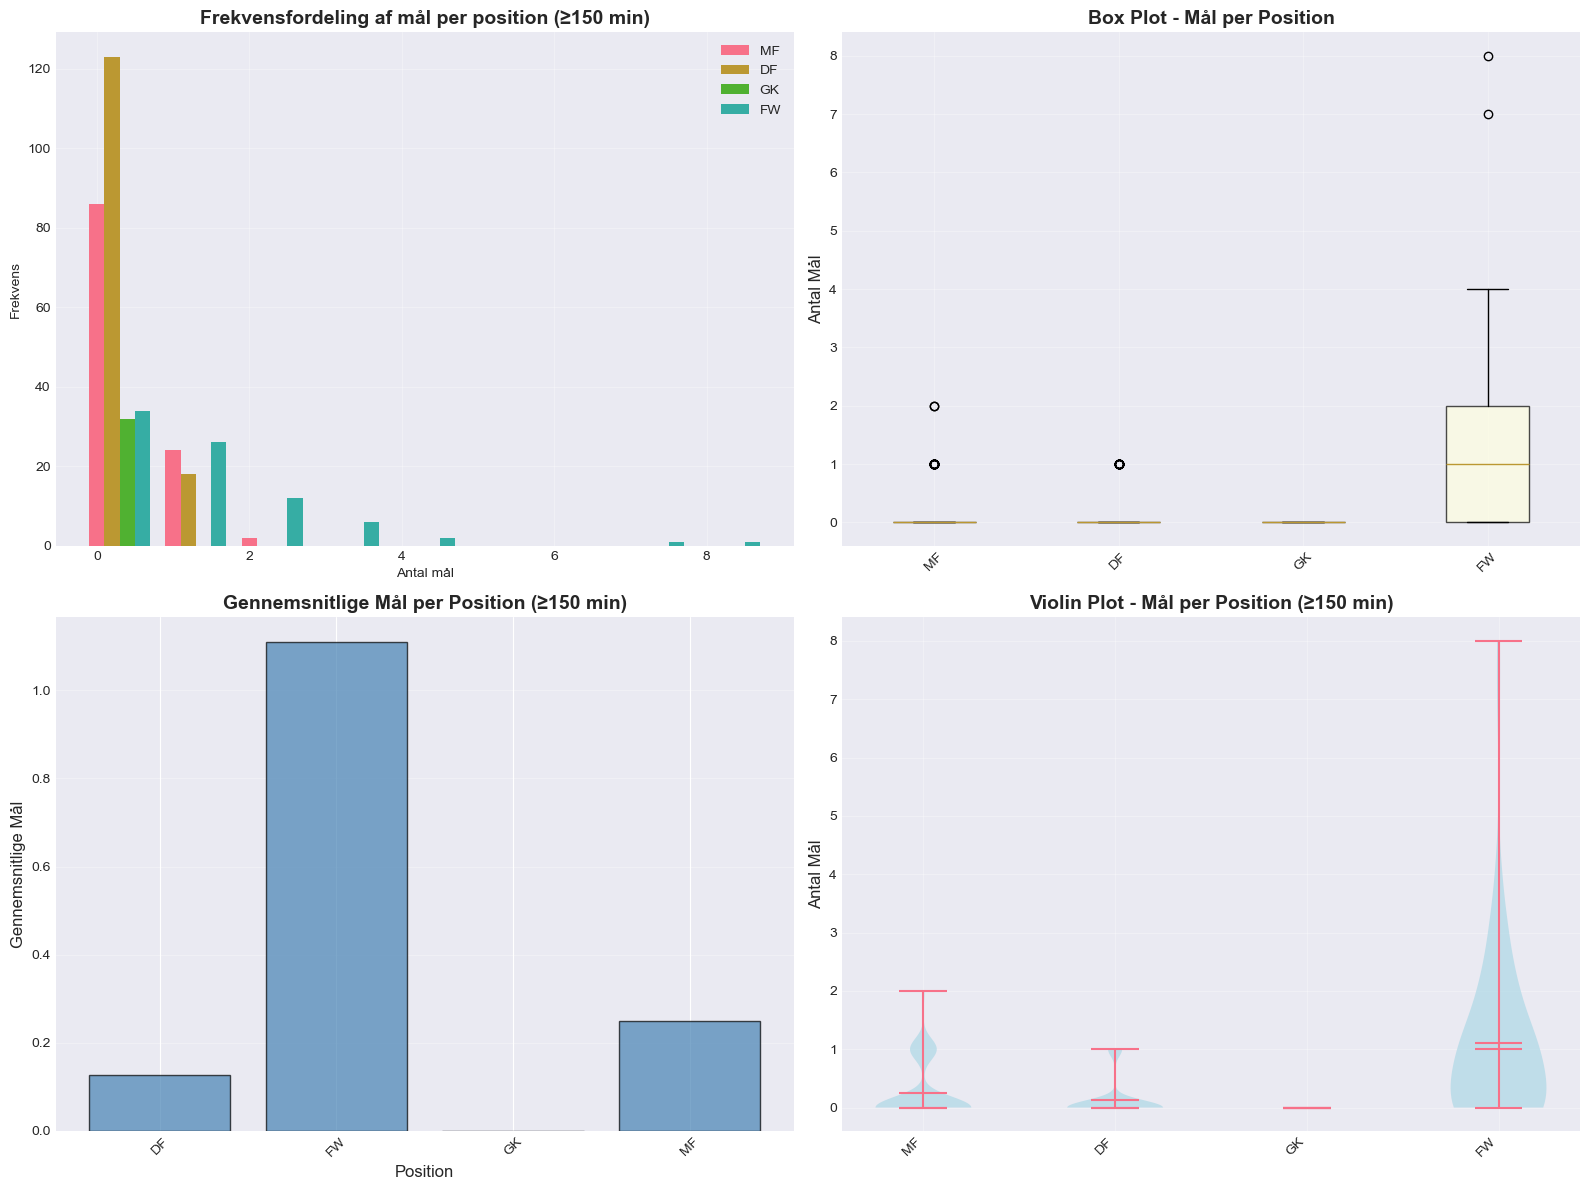

In [17]:
# Filtrer først: kun spillere med mindst 150 minutter
df_filtered = df[df['minutes'] >= 150]

positions = df_filtered['position'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram for goals fordelt på position
bins = np.arange(0, df_filtered['goals'].max() + 2)
bin_centers = bins[:-1]
width = 0.2

for i, pos in enumerate(positions):
    pos_data = df_filtered[df_filtered['position'] == pos]['goals']
    counts, _ = np.histogram(pos_data, bins=bins)
    axes[0, 0].bar(bin_centers + i * width, counts,width=width,label=pos)

axes[0, 0].set_xlabel('Antal mål')
axes[0, 0].set_ylabel('Frekvens')
axes[0, 0].set_title('Frekvensfordeling af mål per position (≥150 min)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot sammenligning
data_by_position = [df_filtered[df_filtered['position'] == pos]['goals'].dropna() for pos in positions]
bp = axes[0, 1].boxplot(data_by_position, tick_labels=positions, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors[:len(positions)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_ylabel('Antal Mål', fontsize=12)
axes[0, 1].set_title('Box Plot - Mål per Position', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Frekvenstabel per position
position_goals_summary = df_filtered.groupby('position')['goals'].agg(['mean', 'median', 'std', 'count'])
print("Sammenligning af Mål per Position (≥150 min):")
print("=" * 70)
print(position_goals_summary.round(2).to_string())

# Bar chart for gennemsnitlige mål per position
axes[1, 0].bar(position_goals_summary.index, position_goals_summary['mean'], 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Position', fontsize=12)
axes[1, 0].set_ylabel('Gennemsnitlige Mål', fontsize=12)
axes[1, 0].set_title('Gennemsnitlige Mål per Position (≥150 min)', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Violin plot for sammenligning
parts = axes[1, 1].violinplot(data_by_position, positions=range(len(positions)), 
                              showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)
axes[1, 1].set_xticks(range(len(positions)))
axes[1, 1].set_xticklabels(positions, rotation=45, ha='right')
axes[1, 1].set_ylabel('Antal Mål', fontsize=12)
axes[1, 1].set_title('Violin Plot - Mål per Position (≥150 min)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Komplet Oversigt - Alle Deskriptive Statistikker

Lad os se en komplet oversigt over alle deskriptive statistikker for vores numeriske variabler.


In [18]:
# Kun variabler vi vil analysere, hentet fra de allerede filtrerede datasæt
numerical_vars = ['goals', 'assists']



descriptive_stats = pd.DataFrame({
    'Variabel': numerical_vars,
    'Gennemsnit': [df_goals_filtered['goals'].mean(), df_assists_filtered['assists'].mean()],
    'Median': [df_goals_filtered['goals'].median(), df_assists_filtered['assists'].median()],
    'Std': [df_goals_filtered['goals'].std(ddof=1), df_assists_filtered['assists'].std(ddof=1)],
    'Varians': [df_goals_filtered['goals'].var(ddof=1), df_assists_filtered['assists'].var(ddof=1)],
    'Min': [df_goals_filtered['goals'].min(), df_assists_filtered['assists'].min()],
    'Max': [df_goals_filtered['goals'].max(), df_assists_filtered['assists'].max()],
    'Range': [df_goals_filtered['goals'].max() - df_goals_filtered['goals'].min(),
              df_assists_filtered['assists'].max() - df_assists_filtered['assists'].min()],
    'Q1': [df_goals_filtered['goals'].quantile(0.25), df_assists_filtered['assists'].quantile(0.25)],
    'Q3': [df_goals_filtered['goals'].quantile(0.75), df_assists_filtered['assists'].quantile(0.75)],
    'IQR': [df_goals_filtered['goals'].quantile(0.75) - df_goals_filtered['goals'].quantile(0.25),
            df_assists_filtered['assists'].quantile(0.75) - df_assists_filtered['assists'].quantile(0.25)]
})

# Afrunding
for col in descriptive_stats.columns:
    if col != 'Variabel':
        descriptive_stats[col] = descriptive_stats[col].round(2)

print("KOMPLET OVERSIGT - DESKRIPTIVE STATISTIKKER")
print("=" * 100)
print(descriptive_stats.to_string(index=False, col_space=11))


KOMPLET OVERSIGT - DESKRIPTIVE STATISTIKKER
   Variabel  Gennemsnit      Median         Std     Varians         Min         Max       Range          Q1          Q3         IQR
      goals        1.11         1.0        1.46        2.12           0           8           8         0.0         2.0         2.0
    assists        0.37         0.0        0.70        0.49           0           3           3         0.0         1.0         1.0


In [19]:
# Brug pandas describe() metode for komplet oversigt
desc_stats = pd.DataFrame({
    'Goals': df_goals_filtered['goals'].describe().round(2),
    'Assists': df_assists_filtered['assists'].describe().round(2)
})
print("=" * 80)
print("PANDAS DESCRIBE() - AUTOMATISK BESKRIVENDE STATISTIK")
print("=" * 80)
print(desc_stats)


PANDAS DESCRIBE() - AUTOMATISK BESKRIVENDE STATISTIK
       Goals  Assists
count  82.00   194.00
mean    1.11     0.37
std     1.46     0.70
min     0.00     0.00
25%     0.00     0.00
50%     1.00     0.00
75%     2.00     1.00
max     8.00     3.00


## 5. Opsummering og Nøglebegreber

### Mål for Central Tendens
- **Gennemsnit (Mean)**: Summen af alle værdier divideret med antallet. Påvirkes af outliers.
- **Median**: Den midterste værdi. Robust mod outliers.
- **Typetal (Mode)**: Den hyppigste værdi. Nyttig for kategoriske data.

### Mål for Variabilitet
- **Range**: Forskellen mellem max og min værdi. Simpel men påvirkes af outliers.
- **Varians**: Gennemsnitlig kvadratisk afstand fra gennemsnittet.
- **Standardafvigelse**: Kvadratroden af variansen. Samme enhed som dataene.
- **IQR**: Forskellen mellem Q3 og Q1. Robust mod outliers.

### Frekvensfordelinger
- **Frekvenstabeller**: Viser antal forekomster for hver værdi/kategori.
- **Histogrammer**: Grafisk repræsentation af frekvensfordelinger.
- **Kumulative frekvenser**: Akkumuleret frekvens op til en given værdi.

### Hvornår bruger man hvad?
- **Gennemsnit**: Når data er normalfordelt og uden ekstreme outliers.
- **Median**: Når data er skæve eller har outliers.
- **Standardafvigelse**: Når man vil forstå spredning i samme enhed som dataene.
- **IQR**: Når man vil have en robust mål for spredning.


## 6. Opgaver og Spørgsmål til Klassen

### Opgave 1: Beregning af Central Tendens
Beregn gennemsnit, median og typetal for variablen `assists` i datasættet. Sammenlign resultaterne og forklar eventuelle forskelle.

### Opgave 2: Variabilitet
Beregn range, varians, standardafvigelse og IQR for variablen `minutes`. Hvilket mål synes du bedst beskriver spredningen i dataene? Hvorfor?

### Opgave 3: Frekvensfordeling
Opret en frekvenstabel og histogram for variablen `age`. Hvad kan du konkludere om aldersfordelingen blandt spillere?

### Opgave 4: Sammenligning
Sammenlign gennemsnit og standardafvigelse for `goals` mellem forskellige positioner (FW, MF, DF, GK). Hvilken position har højeste gennemsnit? Hvilken har størst variabilitet?

### Opgave 5: Programmering
Skriv en funktion der tager en pandas Series som input og returnerer en dictionary med alle mål for central tendens og variabilitet.

### Spørgsmål til Diskussion
1. Hvornår ville du foretrække at bruge median frem for gennemsnit?
2. Hvad betyder det, hvis standardafvigelsen er meget høj sammenlignet med gennemsnittet?
3. Hvordan kan frekvensfordelinger hjælpe med at identificere outliers?
4. Hvad er forskellen mellem varians og standardafvigelse, og hvorfor bruger vi ofte standardafvigelse?


In [ ]:
# Eksempel løsning til Opgave 5
def calculate_descriptive_stats(data_series):
    """
    Beregner alle deskriptive statistikker for en pandas Series
    
    Parameters:
    -----------
    data_series : pandas.Series
        Dataene der skal analyseres
    
    Returns:
    --------
    dict : Dictionary med alle deskriptive statistikker
    """
    stats = {
        # Central Tendency
        'mean': data_series.mean(),
        'median': data_series.median(),
        'mode': data_series.mode().iloc[0] if len(data_series.mode()) > 0 else None,
        
        # Variability
        'std_dev': data_series.std(ddof=1),
        'variance': data_series.var(ddof=1),
        'range': data_series.max() - data_series.min(),
        'min': data_series.min(),
        'max': data_series.max(),
        'q1': data_series.quantile(0.25),
        'q3': data_series.quantile(0.75),
        'iqr': data_series.quantile(0.75) - data_series.quantile(0.25),
        
        # Additional
        'count': data_series.count(),
        'skewness': data_series.skew(),
        'kurtosis': data_series.kurtosis()
    }
    return stats

# Test funktionen
example_stats = calculate_descriptive_stats(df['goals'])
print("Eksempel: Deskriptive statistikker for 'goals'")
print("=" * 60)
for key, value in example_stats.items():
    if isinstance(value, float):
        print(f"{key:15s}: {value:.2f}")
    else:
        print(f"{key:15s}: {value}")


## 7. Referencer og Yderligere Læsning

### Python Biblioteker Brugt
- **pandas**: Data manipulation og analyse
- **numpy**: Numeriske beregninger
- **matplotlib**: Grundlæggende visualisering
- **seaborn**: Statistisk visualisering
- **scipy**: Videnskabelige beregninger

### Nøglebegreber
- Descriptive Statistics
- Measures of Central Tendency
- Measures of Variability/Dispersion
- Frequency Distributions
- Histograms
- Box Plots
- Cumulative Frequency

### Anbefalede Ressourcer
1. Pandas dokumentation: https://pandas.pydata.org/docs/
2. NumPy dokumentation: https://numpy.org/doc/
3. Matplotlib dokumentation: https://matplotlib.org/stable/contents.html
4. Seaborn dokumentation: https://seaborn.pydata.org/

---

**Notebook oprettet for:** Deskriptiv Statistik - Undervisningsmateriale  
**Data:** player_stats.csv (VM 2022 fodboldstatistikker)  
**Dato:** 2024
